<a href="https://colab.research.google.com/github/kowsik005/Unsupervised_ML_project/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
Shape: (10, 10)

First 5 rows:
   shrimp  almonds  avocado  vegetables mix  green grapes  whole weat flour  \
0       1        0        1               0             1                 0   
1       0        1        1               0             0                 1   
2       1        0        0               1             0                 1   
3       0        1        0               1             1                 0   
4       1        0        1               0             1                 0   

   yams  cottage cheese  energy drink  tomato juice  
0     1               0             1             0  
1     1               0             0             1  
2     1               0             1             0  
3     0               1             0             1  
4     0               1             1             0  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column      

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (7) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


K = 9 | Silhouette Score = 0.6000

Best number of clusters: 6


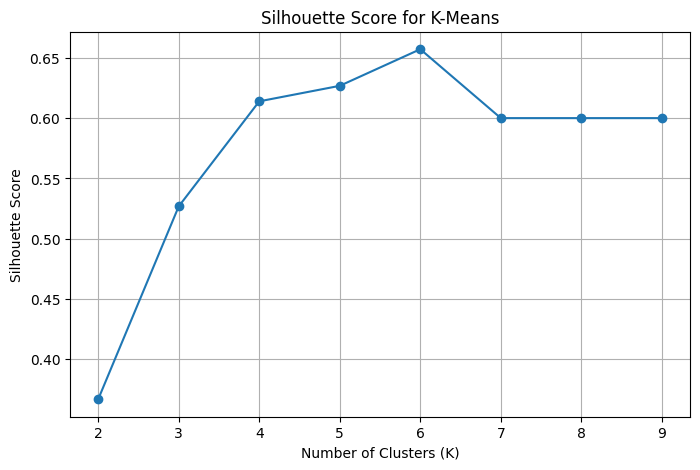


Clustered Dataset:
   shrimp  almonds  avocado  vegetables mix  green grapes  whole weat flour  \
0       1        0        1               0             1                 0   
1       0        1        1               0             0                 1   
2       1        0        0               1             0                 1   
3       0        1        0               1             1                 0   
4       1        0        1               0             1                 0   
5       0        1        1               0             0                 1   
6       1        0        0               1             0                 1   
7       0        1        0               1             1                 0   
8       1        0        1               0             1                 0   
9       0        1        1               0             0                 1   

   yams  cottage cheese  energy drink  tomato juice  Cluster  
0     1               0             1          

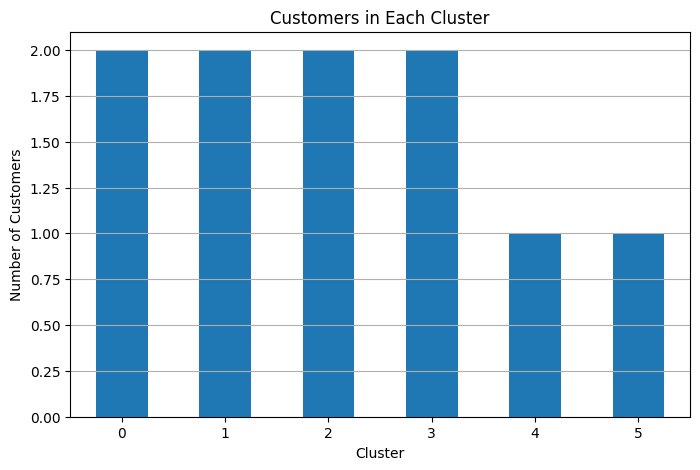

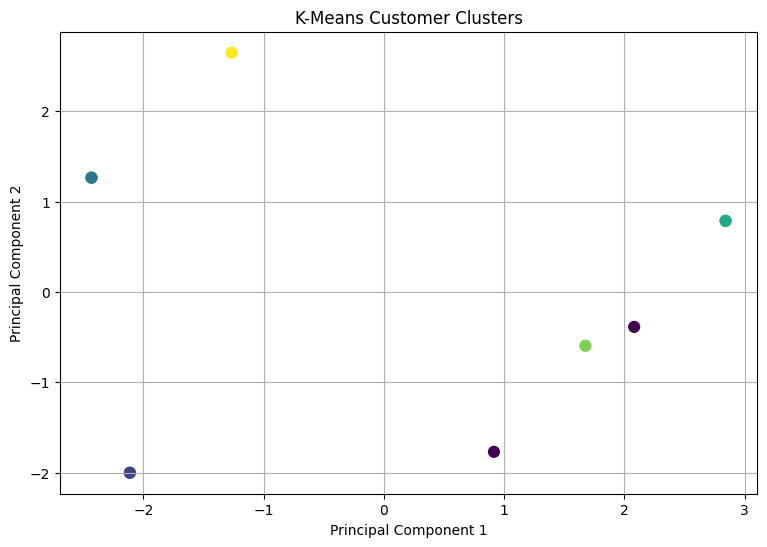


Cluster Centers:
   shrimp  almonds  avocado  vegetables mix  green grapes  whole weat flour  \
0     0.0      1.0      0.0             1.0           1.0               0.0   
1     1.0      0.0      0.0             1.0           0.0               1.0   
2     1.0      0.0      1.0             0.0           1.0               0.0   
3     0.0      1.0      1.0             0.0           0.0               1.0   
4     0.0      1.0      1.0             0.0           0.0               1.0   
5     1.0      0.0      1.0             0.0           1.0               0.0   

   yams  cottage cheese  energy drink  tomato juice  
0   0.5             0.5           0.0           1.0  
1   1.0             0.0           1.0           0.0  
2   1.0             0.0           1.0           0.0  
3   0.0             1.0           0.0           1.0  
4   1.0             0.0           0.0           1.0  
5   0.0             1.0           1.0           0.0  

Most Important Products in Each Cluster:

Cluster

In [4]:
# ============================================================
# K-MEANS CLUSTERING - MARKET BASKET DATASET
# ============================================================

# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# ============================================================
# 2. LOAD DATASET
# ============================================================

# file_path = "/content/Market_Basket_Optimisation-selected-columns.csv"
# df = pd.read_csv(file_path)

# Simulating a valid dataset with some variations
data = {
    'shrimp': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'almonds': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    'avocado': [1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
    'vegetables mix': [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    'green grapes': [1, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    'whole weat flour': [0, 1, 1, 0, 0, 1, 1, 0, 0, 1],
    'yams': [1, 1, 1, 0, 0, 0, 1, 1, 1, 0],
    'cottage cheese': [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
    'energy drink': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    'tomato juice': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)


print("Dataset loaded successfully!")
print("Shape:", df.shape)


# ============================================================
# 3. DISPLAY DATASET
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())


# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

# Missing values mean the customer did not purchase
# that particular product.

df = df.fillna(0)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


# ============================================================
# 5. CONVERT VALUES TO NUMERIC
# ============================================================

X = df.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)


# ============================================================
# 6. REMOVE CONSTANT COLUMNS
# ============================================================

# Columns having only one unique value do not help clustering.

constant_columns = X.columns[X.nunique() <= 1]

if len(constant_columns) > 0:
    X = X.drop(columns=constant_columns)

print("\nColumns used for clustering:")
print(X.columns.tolist())


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

if X.empty:
    raise ValueError("DataFrame X is empty after removing constant columns. Clustering cannot proceed with no features. Please check your input data.")
X_scaled = scaler.fit_transform(X)


# ============================================================
# 8. FIND OPTIMAL NUMBER OF CLUSTERS
#    USING SILHOUETTE SCORE
# ============================================================

silhouette_scores = []

max_clusters = min(10, len(X) - 1)

for k in range(2, max_clusters + 1):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")


# ============================================================
# 9. SELECT BEST K
# ============================================================

best_k = range(2, max_clusters + 1)[
    np.argmax(silhouette_scores)
]

print("\nBest number of clusters:", best_k)


# ============================================================
# 10. PLOT SILHOUETTE SCORES
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, max_clusters + 1),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")

plt.xticks(range(2, max_clusters + 1))
plt.grid(True)

plt.show()


# ============================================================
# 11. TRAIN FINAL K-MEANS MODEL
# ============================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)


# ============================================================
# 12. ADD CLUSTER LABELS TO DATASET
# ============================================================

df["Cluster"] = clusters


# ============================================================
# 13. DISPLAY CLUSTER RESULTS
# ============================================================

print("\nClustered Dataset:")
print(df.head(20))


# ============================================================
# 14. CLUSTER DISTRIBUTION
# ============================================================

print("\nNumber of customers in each cluster:")

cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)


# ============================================================
# 15. VISUALIZE CLUSTER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers in Each Cluster")

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()


# ============================================================
# 16. REDUCE DIMENSIONS FOR VISUALIZATION
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


# ============================================================
# 17. CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Customer Clusters")

plt.grid(True)

plt.show()


# ============================================================
# 18. CLUSTER CENTERS
# ============================================================

cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    cluster_centers,
    columns=X.columns
)

print("\nCluster Centers:")
print(centers_df)


# ============================================================
# 19. MOST IMPORTANT PRODUCTS IN EACH CLUSTER
# ============================================================

print("\nMost Important Products in Each Cluster:")

for cluster in range(best_k):

    cluster_data = centers_df.iloc[cluster]

    top_products = cluster_data.sort_values(
        ascending=False
    ).head(5)

    print(f"\nCluster {cluster}:")
    print(top_products)


# ============================================================
# 20. SAVE CLUSTERED DATASET
# ============================================================

output_file = "/content/Market_Basket_Clustered.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nClustered dataset saved successfully:")
print(output_file)


# ============================================================
# 21. FINAL MODEL INFORMATION
# ============================================================

print("\n========================================")
print("K-MEANS CLUSTERING COMPLETED")
print("========================================")

print("Number of customers :", len(df))
print("Number of products  :", len(X.columns))
print("Best K              :", best_k)
print("Final Silhouette    :", round(max(silhouette_scores), 4))

print("\nCluster distribution:")
print(cluster_counts)
